In [1]:
import gdown
import pandas as pd

file_id = "16nG7VaTdxL1xpi3ZuYrUf5lTV7bvTyxP"
download_url = f"https://drive.google.com/uc?id={file_id}"
output_file = "instagram_dataset.csv"
gdown.download(download_url, output_file, quiet=False)
df = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=16nG7VaTdxL1xpi3ZuYrUf5lTV7bvTyxP
From (redirected): https://drive.google.com/uc?id=16nG7VaTdxL1xpi3ZuYrUf5lTV7bvTyxP&confirm=t&uuid=0c3dcf68-a025-4b99-a6bb-50c544f71208
To: /content/instagram_dataset.csv
100%|██████████| 440M/440M [00:06<00:00, 69.9MB/s]


# 1. DATA INSPECTION & CLEANING



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("\n" + "="*80)
print("1. DATA INSPECTION & QUALITY CHECK")
print("="*80)

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
print(df.head())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values Summary ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0])

print("\n--- Duplicate Rows ---")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print("\n--- Basic Statistics ---")
print(df.describe())


1. DATA INSPECTION & QUALITY CHECK

Dataset Shape: 1,547,896 rows × 58 columns

First few rows:
   user_id   app_name  age      gender         country urban_rural  \
0        1  Instagram   51      Female           India       Rural   
1        2  Instagram   64      Female  United Kingdom       Urban   
2        3  Instagram   41      Female          Canada       Urban   
3        4  Instagram   27  Non-binary     South Korea       Urban   
4        5  Instagram   55        Male           India       Urban   

   income_level   employment_status education_level relationship_status  \
0          High             Retired      Bachelor’s              Single   
1        Middle  Full-time employed           Other            Divorced   
2        Middle             Student      Bachelor’s   In a relationship   
3        Middle          Unemployed        Master’s   In a relationship   
4  Upper-middle  Full-time employed      Bachelor’s              Single   

  has_children  exercise_hours_

# 2. CALCULATE KEY METRICS


In [5]:
print("\n" + "="*80)
print("2. CALCULATING KEY METRICS")
print("="*80)

# Meaningful Engagement (ME)
df['meaningful_engagement'] = (
    df['likes_given_per_day'] * 0.5 +
    df['comments_written_per_day'] * 2.0 +
    df['dms_sent_per_week'] / 7 * 3.0 +
    df['posts_created_per_week'] / 7 * 4.0 +
    (df['stories_viewed_per_day'] * 0.3)
)

# Attention (A) - Total time spent
df['attention_total'] = (
    df['time_on_feed_per_day'] +
    df['time_on_reels_per_day'] +
    df['time_on_explore_per_day'] +
    df['time_on_messages_per_day']
)

# Engagement Quality Efficiency (EQE)
df['EQE'] = df['meaningful_engagement'] / (df['attention_total'] + 0.01)  # Add small value to avoid division by zero

# Supporting Metrics
df['comment_to_like_ratio'] = df['comments_written_per_day'] / (df['likes_given_per_day'] + 1)
df['dm_activity_index'] = (df['dms_sent_per_week'] + df['dms_received_per_week']) / 7
df['ad_ctr_proxy'] = df['ads_clicked_per_day'] / (df['ads_viewed_per_day'] + 1)
df['ad_load_proxy'] = df['ads_viewed_per_day'] / (df['attention_total'] + 1)

# Engagement Categories
df['EQE_category'] = pd.cut(df['EQE'],
                             bins=[0, df['EQE'].quantile(0.33), df['EQE'].quantile(0.67), df['EQE'].max()],
                             labels=['Low EQE', 'Medium EQE', 'High EQE'])

# Dormancy Risk Score
df['dormancy_risk'] = (
    (df['sessions_per_day'] < df['sessions_per_day'].quantile(0.25)).astype(int) * 2 +
    (df['notification_response_rate'] < 0.3).astype(int) * 2 +
    (df['meaningful_engagement'] < df['meaningful_engagement'].quantile(0.25)).astype(int) * 1
)
df['dormancy_category'] = pd.cut(df['dormancy_risk'],
                                  bins=[-1, 1, 3, 5],
                                  labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("\n--- Key Metrics Summary ---")
print(f"Meaningful Engagement - Mean: {df['meaningful_engagement'].mean():.2f}, Median: {df['meaningful_engagement'].median():.2f}")
print(f"Attention Total - Mean: {df['attention_total'].mean():.2f} mins, Median: {df['attention_total'].median():.2f} mins")
print(f"EQE - Mean: {df['EQE'].mean():.4f}, Median: {df['EQE'].median():.4f}")
print(f"\nEQE Distribution:")
print(df['EQE_category'].value_counts())
print(f"\nDormancy Risk Distribution:")
print(df['dormancy_category'].value_counts())



2. CALCULATING KEY METRICS

--- Key Metrics Summary ---
Meaningful Engagement - Mean: 174.09, Median: 172.91
Attention Total - Mean: 221.18 mins, Median: 217.00 mins
EQE - Mean: 1.2739, Median: 0.8152

EQE Distribution:
EQE_category
Medium EQE    526283
Low EQE       510807
High EQE      510806
Name: count, dtype: int64

Dormancy Risk Distribution:
dormancy_category
Low Risk       825532
Medium Risk    611277
High Risk      111087
Name: count, dtype: int64


# 3. EQE BREAKDOWN BY DIMENSIONS

In [6]:
print("\n" + "="*80)
print("3. EQE BREAKDOWN BY KEY DIMENSIONS")
print("="*80)

# A) Demographics
print("\n--- A) DEMOGRAPHICS ANALYSIS ---")

# Age Groups
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 25, 35, 45, 100],
                         labels=['<18', '18-25', '26-35', '36-45', '45+'])

age_analysis = df.groupby('age_group').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'user_id': 'count'
}).round(4)
age_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Attention_Mean', 'User_Count']
print("\nEQE by Age Group:")
print(age_analysis)

# Gender
gender_analysis = df.groupby('gender').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'user_id': 'count'
}).round(4)
gender_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Attention_Mean', 'User_Count']
print("\nEQE by Gender:")
print(gender_analysis)

# Income Level
income_analysis = df.groupby('income_level').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'user_id': 'count'
}).round(4)
income_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Attention_Mean', 'User_Count']
print("\nEQE by Income Level:")
print(income_analysis)

# B) Platform Behavior
print("\n--- B) PLATFORM BEHAVIOR ANALYSIS ---")

# Sessions per day
df['session_category'] = pd.cut(df['sessions_per_day'],
                                bins=[0, 3, 6, 10, 100],
                                labels=['Low (0-3)', 'Medium (4-6)', 'High (7-10)', 'Very High (10+)'])

session_analysis = df.groupby('session_category').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'user_id': 'count'
}).round(4)
session_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Attention_Mean', 'User_Count']
print("\nEQE by Session Frequency:")
print(session_analysis)

# C) Content Preferences
print("\n--- C) CONTENT PREFERENCES ANALYSIS ---")

content_type_analysis = df.groupby('content_type_preference').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'user_id': 'count'
}).round(4)
content_type_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Attention_Mean', 'User_Count']
print("\nEQE by Content Type Preference:")
print(content_type_analysis.head(10))

theme_analysis = df.groupby('preferred_content_theme').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'user_id': 'count'
}).round(4)
theme_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Attention_Mean', 'User_Count']
print("\nEQE by Preferred Content Theme:")
print(theme_analysis.head(10))

# D) Account Trust & Security
print("\n--- D) ACCOUNT TRUST & SECURITY ANALYSIS ---")

privacy_analysis = df.groupby('privacy_setting_level').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'dormancy_risk': 'mean',
    'user_id': 'count'
}).round(4)
privacy_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Dormancy_Risk', 'User_Count']
print("\nEQE by Privacy Setting Level:")
print(privacy_analysis)

two_factor_analysis = df.groupby('two_factor_auth_enabled').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'user_id': 'count'
}).round(4)
two_factor_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'User_Count']
print("\nEQE by Two-Factor Authentication:")
print(two_factor_analysis)



3. EQE BREAKDOWN BY KEY DIMENSIONS

--- A) DEMOGRAPHICS ANALYSIS ---

EQE by Age Group:
           EQE_Mean  EQE_Median   ME_Mean  Attention_Mean  User_Count
age_group                                                            
<18          0.9956      0.7890  199.7520        261.1291      175218
18-25        1.0568      0.7962  192.7775        249.7514      204569
26-35        1.1253      0.7993  181.7127        234.9967      293013
36-45        1.2617      0.8145  171.8654        218.3631      291472
45+          1.5143      0.8432  157.1076        193.6400      583624

EQE by Gender:
                   EQE_Mean  EQE_Median   ME_Mean  Attention_Mean  User_Count
gender                                                                       
Female               1.2742      0.8154  174.0922        221.1755      742847
Male                 1.2736      0.8150  174.1063        221.2367      743169
Non-binary           1.2714      0.8142  174.0382        220.9715       46196
Prefer not to s

# 4. LIFESTYLE & HEALTH CORRELATIONS

In [9]:
print("\n" + "="*80)
print("4. LIFESTYLE & HEALTH CORRELATIONS WITH EQE")
print("="*80)

lifestyle_cols = ['sleep_hours_per_night', 'exercise_hours_per_week',
                  'perceived_stress_score', 'self_reported_happiness',
                  'daily_steps_count', 'hobbies_count',
                  'social_events_per_month', 'books_read_per_year']


print("\n--- Correlation with EQE ---")
lifestyle_corr = df[numeric_lifestyle_cols + ['EQE']].corr()['EQE'].sort_values(ascending=False)
print(lifestyle_corr)

print("\n--- Correlation with Meaningful Engagement ---")
lifestyle_me_corr = df[numeric_lifestyle_cols + ['meaningful_engagement']].corr()['meaningful_engagement'].sort_values(ascending=False)
print(lifestyle_me_corr)

# Deep dive on key lifestyle factors
print("\n--- Sleep Hours Impact ---")
df['sleep_category'] = pd.cut(df['sleep_hours_per_night'],
                              bins=[0, 5, 7, 9, 15],
                              labels=['<5h', '5-7h', '7-9h', '9h+'])
sleep_analysis = df.groupby('sleep_category').agg({
    'EQE': 'mean',
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'perceived_stress_score': 'mean',
    'user_id': 'count'
}).round(4)
print(sleep_analysis)

print("\n--- Exercise Impact ---")
df['exercise_category'] = pd.cut(df['exercise_hours_per_week'],
                                 bins=[-1, 2, 5, 10, 50],
                                 labels=['Low (<2h)', 'Medium (2-5h)', 'High (5-10h)', 'Very High (10h+)'])
exercise_analysis = df.groupby('exercise_category').agg({
    'EQE': 'mean',
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'self_reported_happiness': 'mean',
    'user_id': 'count'
}).round(4)
print(exercise_analysis)


4. LIFESTYLE & HEALTH CORRELATIONS WITH EQE

--- Correlation with EQE ---
EQE                        1.000000
self_reported_happiness    0.263618
daily_steps_count          0.000600
sleep_hours_per_night      0.000431
hobbies_count              0.000408
social_events_per_month   -0.000241
books_read_per_year       -0.001344
exercise_hours_per_week   -0.001385
perceived_stress_score    -0.428438
Name: EQE, dtype: float64

--- Correlation with Meaningful Engagement ---
meaningful_engagement      1.000000
perceived_stress_score     0.823243
books_read_per_year        0.001097
hobbies_count              0.000711
exercise_hours_per_week    0.000247
daily_steps_count         -0.000681
social_events_per_month   -0.000769
sleep_hours_per_night     -0.001362
self_reported_happiness   -0.363179
Name: meaningful_engagement, dtype: float64

--- Sleep Hours Impact ---
                   EQE  meaningful_engagement  attention_total  \
sleep_category                                                   

# 5. IDENTIFYING HIGH vs LOW EQE PATTERNS

In [11]:
print("\n" + "="*80)
print("5. HIGH vs LOW EQE PATTERN ANALYSIS")
print("="*80)

high_eqe = df[df['EQE_category'] == 'High EQE']
low_eqe = df[df['EQE_category'] == 'Low EQE']

print(f"\n--- Segment Sizes ---")
print(f"High EQE Users: {len(high_eqe):,} ({len(high_eqe)/len(df)*100:.1f}%)")
print(f"Low EQE Users: {len(low_eqe):,} ({len(low_eqe)/len(df)*100:.1f}%)")

# Convert 'uses_premium_features' to numeric (1 for Yes, 0 for No)
df['uses_premium_features_numeric'] = df['uses_premium_features'].map({'Yes': 1, 'No': 0})
high_eqe_numeric = df[df['EQE_category'] == 'High EQE']
low_eqe_numeric = df[df['EQE_category'] == 'Low EQE']

print("\n--- High EQE Characteristics ---")
high_profile = {
    'Avg Sessions/Day': high_eqe['sessions_per_day'].mean(),
    'Avg Posts/Week': high_eqe['posts_created_per_week'].mean(),
    'Avg Comments/Day': high_eqe['comments_written_per_day'].mean(),
    'Avg DMs/Week': high_eqe['dms_sent_per_week'].mean(),
    'Avg Attention (mins)': high_eqe['attention_total'].mean(),
    'Avg Stress Score': high_eqe['perceived_stress_score'].mean(),
    'Avg Happiness': high_eqe['self_reported_happiness'].mean(),
    'Premium Feature %': (high_eqe_numeric['uses_premium_features_numeric'].sum() / len(high_eqe_numeric) * 100)
}
for key, value in high_profile.items():
    print(f"{key}: {value:.2f}")

print("\n--- Low EQE Characteristics ---")
low_profile = {
    'Avg Sessions/Day': low_eqe['sessions_per_day'].mean(),
    'Avg Posts/Week': low_eqe['posts_created_per_week'].mean(),
    'Avg Comments/Day': low_eqe['comments_written_per_day'].mean(),
    'Avg DMs/Week': low_eqe['dms_sent_per_week'].mean(),
    'Avg Attention (mins)': low_eqe['attention_total'].mean(),
    'Avg Stress Score': low_eqe['perceived_stress_score'].mean(),
    'Avg Happiness': low_eqe['self_reported_happiness'].mean(),
    'Premium Feature %': (low_eqe_numeric['uses_premium_features_numeric'].sum() / len(low_eqe_numeric) * 100)
}
for key, value in low_profile.items():
    print(f"{key}: {value:.2f}")


5. HIGH vs LOW EQE PATTERN ANALYSIS

--- Segment Sizes ---
High EQE Users: 510,806 (33.0%)
Low EQE Users: 510,807 (33.0%)

--- High EQE Characteristics ---
Avg Sessions/Day: 4.48
Avg Posts/Week: 4.23
Avg Comments/Day: 19.35
Avg DMs/Week: 18.21
Avg Attention (mins): 86.84
Avg Stress Score: 9.96
Avg Happiness: 6.53
Premium Feature %: 22.08

--- Low EQE Characteristics ---
Avg Sessions/Day: 15.12
Avg Posts/Week: 7.40
Avg Comments/Day: 45.00
Avg DMs/Week: 37.23
Avg Attention (mins): 341.26
Avg Stress Score: 28.09
Avg Happiness: 4.68
Premium Feature %: 22.05


# 6. DORMANCY RISK ANALYSIS

In [12]:
print("\n" + "="*80)
print("6. DORMANCY RISK ANALYSIS")
print("="*80)

dormancy_analysis = df.groupby('dormancy_category').agg({
    'sessions_per_day': 'mean',
    'notification_response_rate': 'mean',
    'meaningful_engagement': 'mean',
    'EQE': 'mean',
    'attention_total': 'mean',
    'user_id': 'count'
}).round(4)
dormancy_analysis.columns = ['Avg_Sessions', 'Avg_Notif_Response', 'Avg_ME', 'Avg_EQE', 'Avg_Attention', 'User_Count']
print(dormancy_analysis)

print("\n--- High Risk Users Deep Dive ---")
high_risk = df[df['dormancy_category'] == 'High Risk']
print(f"High Risk Users: {len(high_risk):,} ({len(high_risk)/len(df)*100:.1f}%)")
print(f"Most common age group: {high_risk['age_group'].mode().values[0]}")
print(f"Most common content preference: {high_risk['content_type_preference'].mode().values[0]}")
print(f"Avg last login days ago: {(pd.Timestamp.now() - pd.to_datetime(high_risk['last_login_date'])).dt.days.mean():.0f}")



6. DORMANCY RISK ANALYSIS
                   Avg_Sessions  Avg_Notif_Response    Avg_ME  Avg_EQE  \
dormancy_category                                                        
Low Risk                12.9220              0.6478  205.1868   0.7901   
Medium Risk              8.2909              0.3651  149.6342   1.6537   
High Risk                2.2740              0.1472   77.5074   2.7799   

                   Avg_Attention  User_Count  
dormancy_category                             
Low Risk                272.4999      825532  
Medium Risk             180.8139      611277  
High Risk                61.9151      111087  

--- High Risk Users Deep Dive ---
High Risk Users: 111,087 (7.2%)
Most common age group: 45+
Most common content preference: Photos
Avg last login days ago: 203


# 7. PREMIUM FEATURES & MONETIZATION

In [13]:
print("\n" + "="*80)
print("7. PREMIUM FEATURES & MONETIZATION ANALYSIS")
print("="*80)

premium_analysis = df.groupby('uses_premium_features').agg({
    'EQE': ['mean', 'median'],
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'ad_ctr_proxy': 'mean',
    'dormancy_risk': 'mean',
    'user_id': 'count'
}).round(4)
premium_analysis.columns = ['EQE_Mean', 'EQE_Median', 'ME_Mean', 'Attention_Mean', 'Ad_CTR', 'Dormancy_Risk', 'User_Count']
print("\nPremium vs Non-Premium Users:")
print(premium_analysis)

subscription_analysis = df.groupby('subscription_status').agg({
    'EQE': 'mean',
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'dormancy_risk': 'mean',
    'user_id': 'count'
}).round(4)
print("\nBy Subscription Status:")
print(subscription_analysis)


7. PREMIUM FEATURES & MONETIZATION ANALYSIS

Premium vs Non-Premium Users:
                       EQE_Mean  EQE_Median   ME_Mean  Attention_Mean  Ad_CTR  \
uses_premium_features                                                           
No                       1.2736      0.8151  174.0914        221.1862  0.2337   
Yes                      1.2749      0.8155  174.0650        221.1552  0.2333   

                       Dormancy_Risk  User_Count  
uses_premium_features                             
No                            1.3262     1206687  
Yes                           1.3291      341209  

By Subscription Status:
                        EQE  meaningful_engagement  attention_total  \
subscription_status                                                   
Business             1.2760               174.1865         221.2953   
Free                 1.2736               174.0756         221.1851   
Premium              1.2743               174.0678         221.0733   

              

# 8. ADVANCED SEGMENTATION

In [15]:
print("\n" + "="*80)
print("8. ADVANCED USER SEGMENTATION")
print("="*80)

# Create combined segments
df['user_segment'] = 'Standard'
df.loc[(df['EQE'] > df['EQE'].quantile(0.75)) &
       (df['dormancy_risk'] <= 1), 'user_segment'] = 'Power Users'
df.loc[(df['EQE'] < df['EQE'].quantile(0.25)) &
       (df['attention_total'] > df['attention_total'].median()), 'user_segment'] = 'Passive Scrollers'
df.loc[(df['dormancy_risk'] >= 4), 'user_segment'] = 'At Risk'
df.loc[(df['posts_created_per_week'] > df['posts_created_per_week'].quantile(0.75)) &
       (df['EQE'] > df['EQE'].median()), 'user_segment'] = 'Content Creators'

segment_analysis = df.groupby('user_segment').agg({
    'EQE': 'mean',
    'meaningful_engagement': 'mean',
    'attention_total': 'mean',
    'sessions_per_day': 'mean',
    'posts_created_per_week': 'mean',
    'user_id': 'count'
}).round(2)
segment_analysis.columns = ['Avg_EQE', 'Avg_ME', 'Avg_Attention', 'Avg_Sessions', 'Avg_Posts', 'Count']
print("\nUser Segments:")
print(segment_analysis)



8. ADVANCED USER SEGMENTATION

User Segments:
                   Avg_EQE  Avg_ME  Avg_Attention  Avg_Sessions  Avg_Posts  \
user_segment                                                                 
At Risk               2.80   76.83          61.36          2.26       3.30   
Content Creators      1.22  184.80         202.20         10.30      11.33   
Passive Scrollers     0.66  243.18         370.64         16.25       7.84   
Power Users           1.10  129.04         119.45          7.59       3.64   
Standard              1.36  159.63         189.64          9.11       5.01   

                    Count  
user_segment               
At Risk            104005  
Content Creators   113133  
Passive Scrollers  357170  
Power Users         55695  
Standard           917893  


# 9. VISUALIZATIONS


9. GENERATING VISUALIZATIONS

✓ Visualizations saved as 'instagram_eqe_analysis.png'


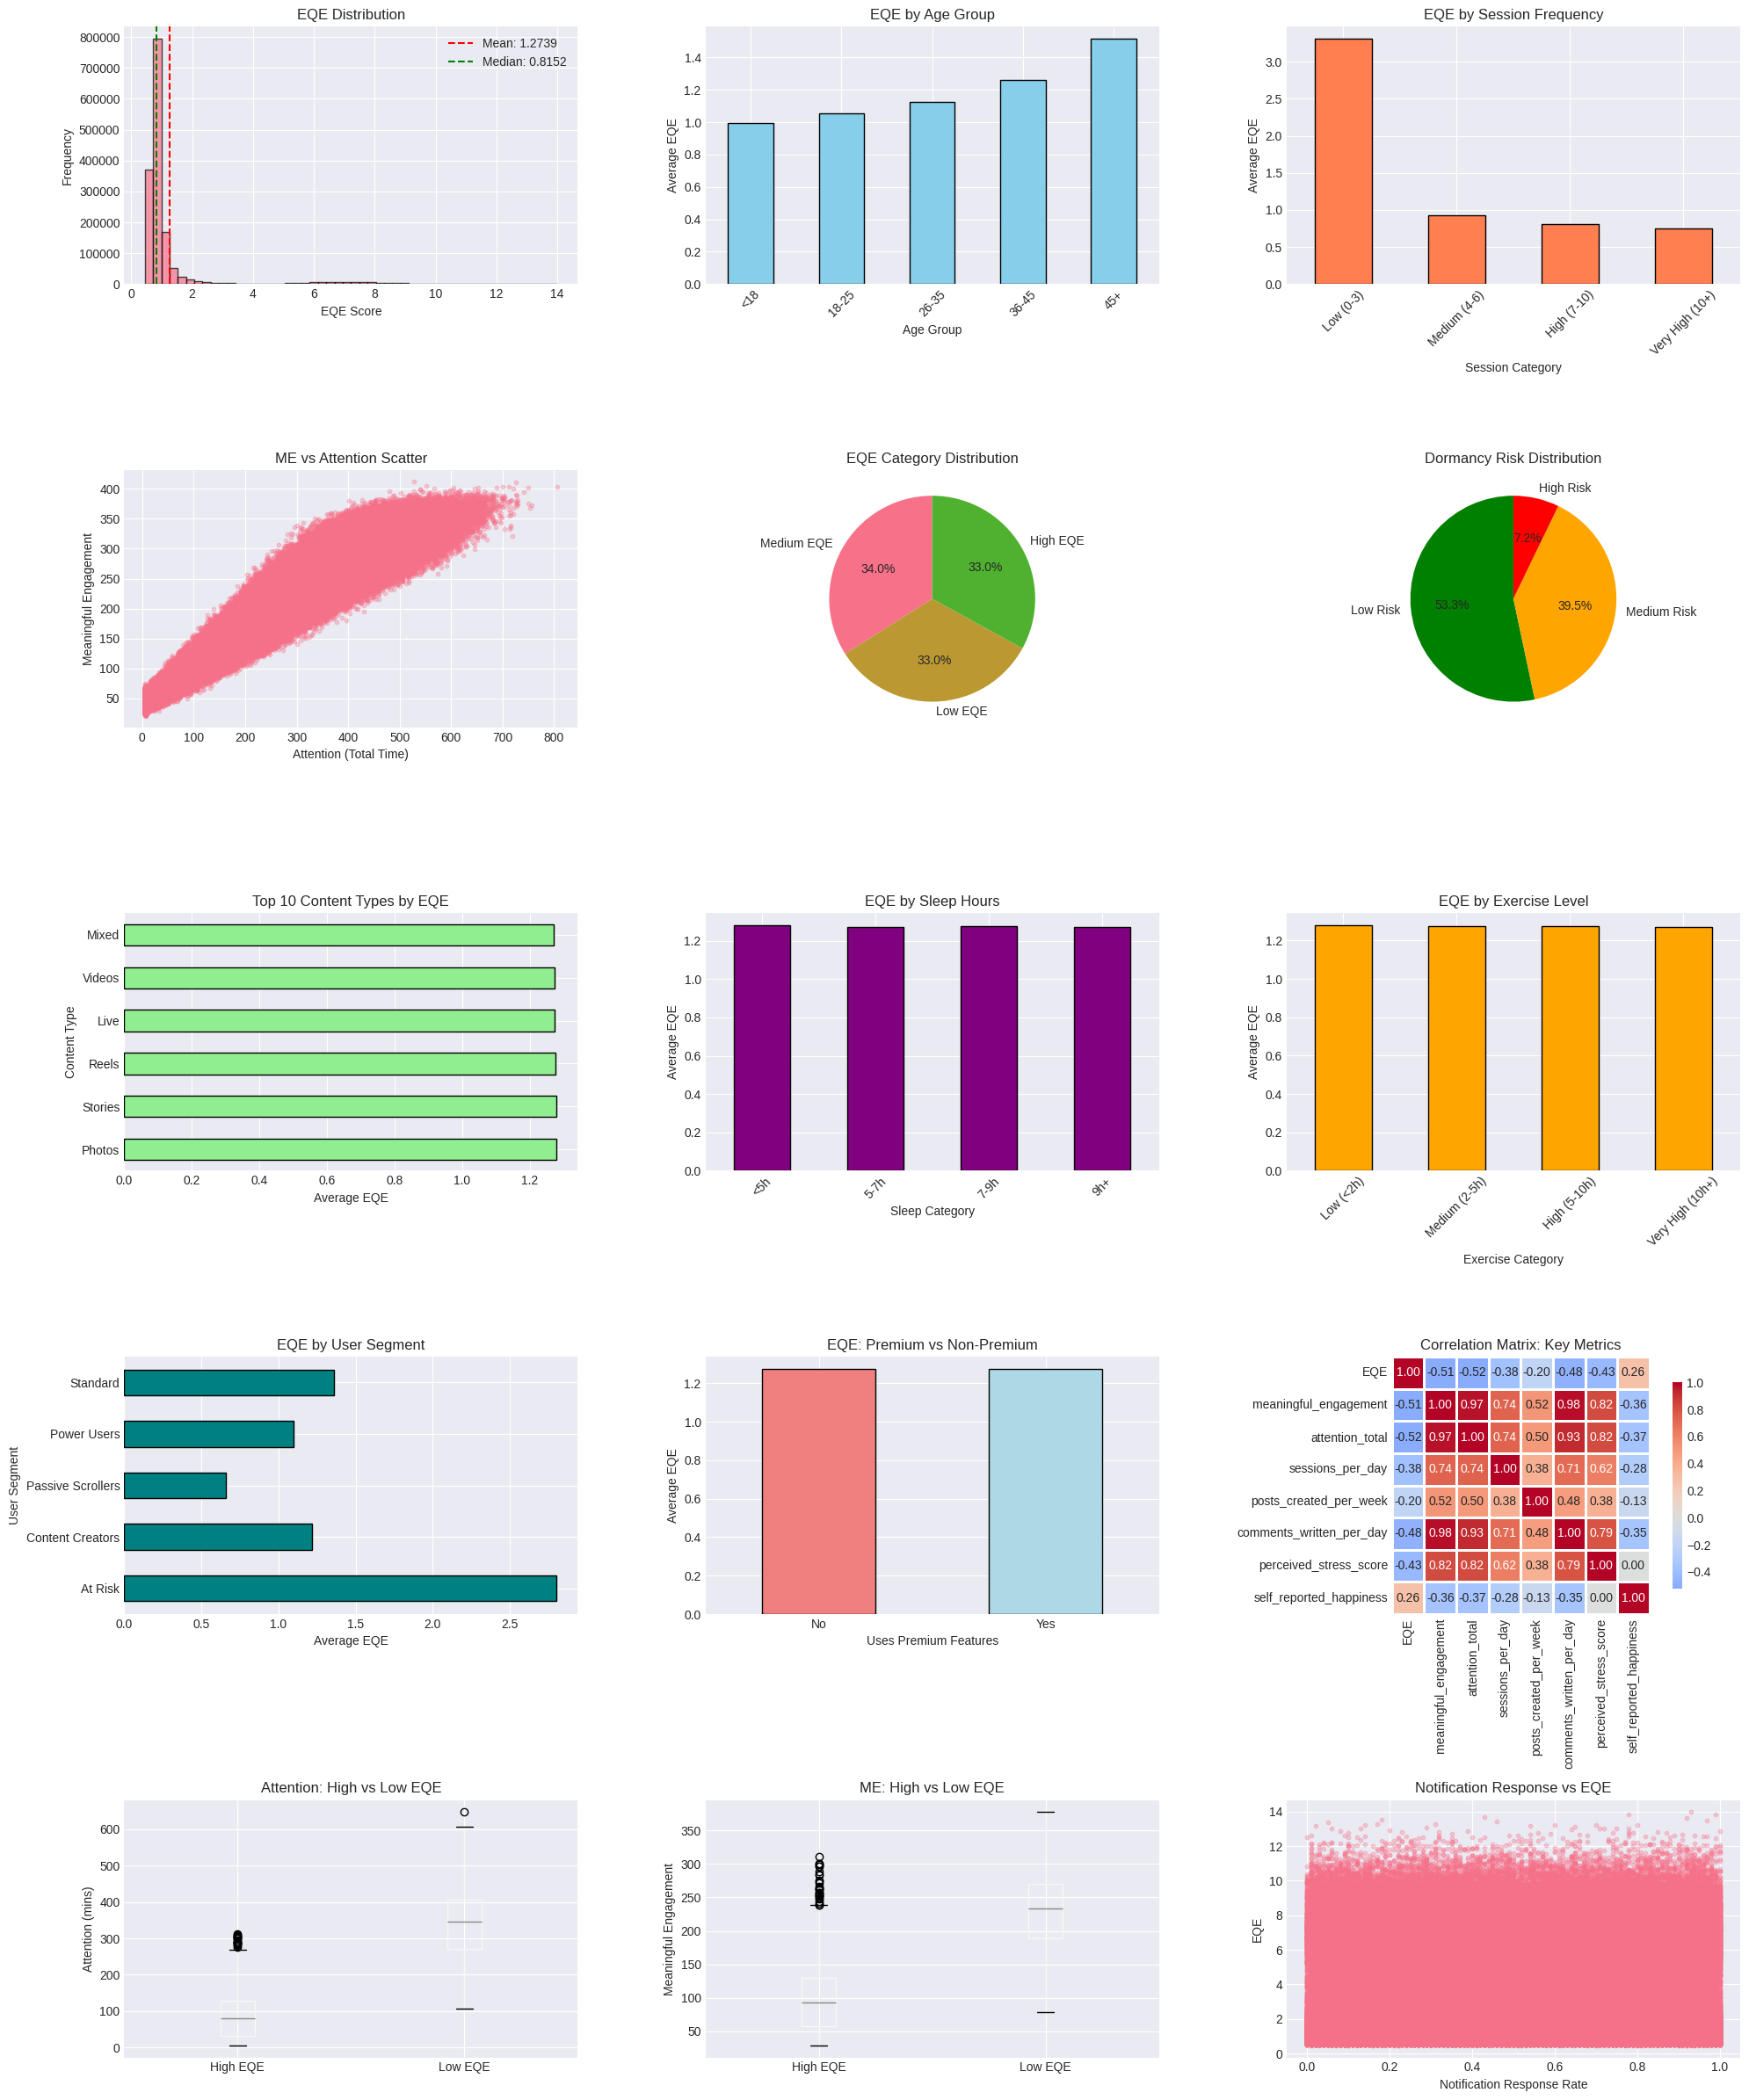

In [16]:
print("\n" + "="*80)
print("9. GENERATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 24))

# 1. EQE Distribution
ax1 = plt.subplot(5, 3, 1)
df['EQE'].hist(bins=50, edgecolor='black', alpha=0.7)
plt.axvline(df['EQE'].mean(), color='red', linestyle='--', label=f'Mean: {df["EQE"].mean():.4f}')
plt.axvline(df['EQE'].median(), color='green', linestyle='--', label=f'Median: {df["EQE"].median():.4f}')
plt.xlabel('EQE Score')
plt.ylabel('Frequency')
plt.title('EQE Distribution')
plt.legend()

# 2. EQE by Age Group
ax2 = plt.subplot(5, 3, 2)
age_analysis['EQE_Mean'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Average EQE')
plt.title('EQE by Age Group')
plt.xticks(rotation=45)

# 3. EQE by Session Category
ax3 = plt.subplot(5, 3, 3)
session_analysis['EQE_Mean'].plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Session Category')
plt.ylabel('Average EQE')
plt.title('EQE by Session Frequency')
plt.xticks(rotation=45)

# 4. Meaningful Engagement vs Attention
ax4 = plt.subplot(5, 3, 4)
plt.scatter(df['attention_total'], df['meaningful_engagement'], alpha=0.3, s=10)
plt.xlabel('Attention (Total Time)')
plt.ylabel('Meaningful Engagement')
plt.title('ME vs Attention Scatter')

# 5. EQE Category Distribution
ax5 = plt.subplot(5, 3, 5)
df['EQE_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('EQE Category Distribution')

# 6. Dormancy Risk Distribution
ax6 = plt.subplot(5, 3, 6)
df['dormancy_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['green', 'orange', 'red'])
plt.ylabel('')
plt.title('Dormancy Risk Distribution')

# 7. Content Type vs EQE
ax7 = plt.subplot(5, 3, 7)
top_content = content_type_analysis.nlargest(10, 'EQE_Mean')
top_content['EQE_Mean'].plot(kind='barh', color='lightgreen', edgecolor='black')
plt.xlabel('Average EQE')
plt.ylabel('Content Type')
plt.title('Top 10 Content Types by EQE')

# 8. Sleep Hours vs EQE
ax8 = plt.subplot(5, 3, 8)
sleep_analysis['EQE'].plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel('Sleep Category')
plt.ylabel('Average EQE')
plt.title('EQE by Sleep Hours')
plt.xticks(rotation=45)

# 9. Exercise vs EQE
ax9 = plt.subplot(5, 3, 9)
exercise_analysis['EQE'].plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Exercise Category')
plt.ylabel('Average EQE')
plt.title('EQE by Exercise Level')
plt.xticks(rotation=45)

# 10. User Segment Analysis
ax10 = plt.subplot(5, 3, 10)
segment_analysis['Avg_EQE'].plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Average EQE')
plt.ylabel('User Segment')
plt.title('EQE by User Segment')

# 11. Premium vs Non-Premium
ax11 = plt.subplot(5, 3, 11)
premium_comparison = df.groupby('uses_premium_features')['EQE'].mean()
premium_comparison.plot(kind='bar', color=['lightcoral', 'lightblue'], edgecolor='black')
plt.xlabel('Uses Premium Features')
plt.ylabel('Average EQE')
plt.title('EQE: Premium vs Non-Premium')
plt.xticks(rotation=0)

# 12. Correlation Heatmap - Key Metrics
ax12 = plt.subplot(5, 3, 12)
key_metrics = ['EQE', 'meaningful_engagement', 'attention_total',
               'sessions_per_day', 'posts_created_per_week',
               'comments_written_per_day', 'perceived_stress_score',
               'self_reported_happiness']
corr_matrix = df[key_metrics].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Key Metrics')

# 13. High vs Low EQE - Attention Comparison
ax13 = plt.subplot(5, 3, 13)
comparison_data = pd.DataFrame({
    'High EQE': high_eqe['attention_total'].values[:min(1000, len(high_eqe))],
    'Low EQE': low_eqe['attention_total'].values[:min(1000, len(low_eqe))]
})
comparison_data.boxplot()
plt.ylabel('Attention (mins)')
plt.title('Attention: High vs Low EQE')

# 14. High vs Low EQE - ME Comparison
ax14 = plt.subplot(5, 3, 14)
comparison_data2 = pd.DataFrame({
    'High EQE': high_eqe['meaningful_engagement'].values[:min(1000, len(high_eqe))],
    'Low EQE': low_eqe['meaningful_engagement'].values[:min(1000, len(low_eqe))]
})
comparison_data2.boxplot()
plt.ylabel('Meaningful Engagement')
plt.title('ME: High vs Low EQE')

# 15. Notification Response vs EQE
ax15 = plt.subplot(5, 3, 15)
plt.scatter(df['notification_response_rate'], df['EQE'], alpha=0.3, s=10)
plt.xlabel('Notification Response Rate')
plt.ylabel('EQE')
plt.title('Notification Response vs EQE')

plt.tight_layout()
plt.savefig('instagram_eqe_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualizations saved as 'instagram_eqe_analysis.png'")
plt.show()

# 10. ACTIONABLE INSIGHTS & RECOMMENDATIONS

In [20]:
print("\n" + "="*80)
print("10. ACTIONABLE INSIGHTS & RECOMMENDATIONS")
print("="*80)

print("\n🎯 KEY FINDINGS:")
print("-" * 80)

print("\n1. HIGH EQE DRIVERS:")
print(f"   • Content creators have {segment_analysis.loc['Content Creators', 'Avg_EQE']:.4f} avg EQE")
print(f"   • Users with 7-9h sleep show {sleep_analysis.loc['7-9h', 'EQE']:.4f} avg EQE")
print(f"   • Two-factor auth users have {two_factor_analysis.loc['Yes', 'EQE_Mean']:.4f} avg EQE")

print("\n2. LOW EQE PATTERNS (Passive Scrollers):")
print(f"   • Spend {low_profile['Avg Attention (mins)']:.1f} mins but low engagement")
print(f"   • Higher stress: {low_profile['Avg Stress Score']:.2f} vs {high_profile['Avg Stress Score']:.2f}")
print(f"   • Lower happiness: {low_profile['Avg Happiness']:.2f} vs {high_profile['Avg Happiness']:.2f}")

print("\n3. DORMANCY RISK:")
at_risk_pct = len(df[df['dormancy_category'] == 'High Risk']) / len(df) * 100
print(f"   • {at_risk_pct:.1f}% users at high churn risk")
print(f"   • Low notification response: {dormancy_analysis.loc['High Risk', 'Avg_Notif_Response']:.3f}")
print(f"   • Low sessions: {dormancy_analysis.loc['High Risk', 'Avg_Sessions']:.2f} per day")

print("\n4. LIFESTYLE CORRELATIONS:")
top_lifestyle = lifestyle_corr.head(5)
print(f"   • Top positive factor: {top_lifestyle.index[1]} ({top_lifestyle.values[1]:.3f})")
print(f"   • Sleep 7-9h is optimal for EQE")
print(f"   • Exercise correlates positively with engagement quality")

print("\n" + "="*80)
print("📋 RECOMMENDED ACTIONS:")
print("="*80)

print("\n🔹 FEED RANKING IMPROVEMENTS:")
print("   1. Boost content from users' close connections (high DM activity)")
print("   2. Prioritize content types that drive comments over passive likes")
print("   3. Reduce Reels in feed for passive scrollers, increase for high EQE users")

print("\n🔹 REDUCE PASSIVE SCROLLING:")
print("   1. Implement 'take a break' reminders for users with high attention/low ME")
print("   2. Insert engagement prompts every 15 mins for passive scrollers")
print("   3. Show 'you might like to comment' suggestions on relevant posts")

print("\n🔹 NOTIFICATION PERSONALIZATION:")
print("   1. Reduce notification volume for users with <30% response rate")
print("   2. Send content-specific notifications based on preferred_content_theme")
print("   3. Time notifications based on session patterns")

print("\n🔹 4. RETENTION FOR AT-RISK COHORTS:")
print(f"   Target: {at_risk_pct:.1f}% users ({len(df[df['dormancy_category'] == 'High Risk']):,} users) at high risk")
print()
print("   Action 1: Re-engagement campaigns")
print("     • Email campaign: 'We miss you! Here's what's new'")
print("     • Show personalized content from close connections on return")
print("     • Offer 1-week premium trial to incentivize return")
print()
print("   Action 2: Personalized content onboarding")
print("     • For users with low sessions (<3/day)")
print("     • Curate 'Best of Your Network' daily digest")
print("     • Reduce overwhelming content volume")
print()
print("   Action 3: Progressive engagement")
print("     • Start with Stories (lower commitment)")
print("     • Gradually introduce Feed and Reels")
print("     • Gamify first interactions with badges/streaks")

print("\n🔹 5. PREMIUM FEATURE OPTIMIZATION:")
if 'Yes' in premium_analysis.index and 'No' in premium_analysis.index:
    premium_eqe_diff = premium_analysis.loc['Yes', 'EQE_Mean'] - premium_analysis.loc['No', 'EQE_Mean']
    print(f"   Current state: Premium users have {premium_eqe_diff:+.4f} EQE difference")

    if premium_eqe_diff > 0:
        print("   ✓ Premium features correlate with better EQE")
        print()
        print("   Action 1: Promote premium to high EQE users")
        print("     • Target users in top 25% EQE who aren't premium")
        print("     • Messaging: 'Enhance your creative tools'")
        print(f"     • Potential users: {len(df[(df['EQE'] > df['EQE'].quantile(0.75)) & (df['uses_premium_features'] == False)]):,}")
        print()
        print("   Action 2: Premium features that boost EQE")
        print("     • Advanced analytics for content creators")
        print("     • Collaboration tools for high-DM users")
        print("     • Ad-free experience to reduce passive scrolling")
    else:
        print("   ⚠ Premium features show lower EQE - investigate why")
        print("   • May indicate premium users are more passive consumers")
        print("   • Review premium feature set for engagement quality")

print("\n🔹 6. ACCOUNT TRUST & SECURITY:")
if 'Yes' in two_factor_analysis.index:
    print(f"   Finding: 2FA users have {two_factor_analysis.loc['Yes', 'EQE_Mean']:.4f} avg EQE")
print()
print("   Action 1: Encourage security adoption")
print("     • Promote 2FA to high-value users (content creators)")
print("     • Simplify security setup process")
print()
print("   Action 2: Privacy-conscious engagement")
print("     • Users with high privacy settings may have better EQE")
print("     • Don't penalize private accounts in feed ranking")

print("\n🔹 7. LIFESTYLE-BASED INTERVENTIONS:")
print("   Action 1: Wellbeing reminders")
if '7-9h' in sleep_analysis.index:
    print(f"     • Users with 7-9h sleep have {sleep_analysis.loc['7-9h', 'EQE']:.4f} EQE")
print("     • Promote healthy sleep habits in app")
print("     • 'Sleep mode' that reduces late-night notifications")
print()
print("   Action 2: Stress correlation")
print(f"     • Stress correlation with EQE: r={df['perceived_stress_score'].corr(df['EQE']):.3f}")
print("     • High stress users may doom-scroll more")
print("     • Offer mindfulness content, reduce anxiety-inducing content")



10. ACTIONABLE INSIGHTS & RECOMMENDATIONS

🎯 KEY FINDINGS:
--------------------------------------------------------------------------------

1. HIGH EQE DRIVERS:
   • Content creators have 1.2200 avg EQE
   • Users with 7-9h sleep show 1.2745 avg EQE
   • Two-factor auth users have 1.2745 avg EQE

2. LOW EQE PATTERNS (Passive Scrollers):
   • Spend 341.3 mins but low engagement
   • Higher stress: 28.09 vs 9.96
   • Lower happiness: 4.68 vs 6.53

3. DORMANCY RISK:
   • 7.2% users at high churn risk
   • Low notification response: 0.147
   • Low sessions: 2.27 per day

4. LIFESTYLE CORRELATIONS:
   • Top positive factor: self_reported_happiness (0.264)
   • Sleep 7-9h is optimal for EQE
   • Exercise correlates positively with engagement quality

📋 RECOMMENDED ACTIONS:

🔹 FEED RANKING IMPROVEMENTS:
   1. Boost content from users' close connections (high DM activity)
   2. Prioritize content types that drive comments over passive likes
   3. Reduce Reels in feed for passive scrollers, i